<a href="https://colab.research.google.com/github/ankitrai6394-web/EDA_zomatoanalysis/blob/main/Fake_job_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving fake_real_job_postings_3000x25.csv to fake_real_job_postings_3000x25.csv


In [ ]:
df = pd.read_csv("fake_real_job_postings_3000x25.csv")

In [ ]:
df.head()

,job_id,job_title,job_description,requirements,benefits,company_name,company_profile,industry,employment_type,location,...,application_deadline,contact_email,company_website,has_logo,num_open_positions,job_function,telecommuting,fraud_reason,text_length,is_fake
0,1,Software Engineer,We are looking for responsibilities fast-paced...,Candidates should have dynamic team skills fas...,We offer required skills fast-paced skills req...,Company_543,Our company growth fast-paced responsibilities...,Marketing,Contract,"Toronto, Canada",...,2024-09-16,hr312@company.com,https://www.company.com,0,3,Management,0,NaN,89,0
1,2,Content Writer,We are looking for required support experience...,Candidates should have required team fast-pace...,We offer fast-paced dynamic dynamic strategy g...,Company_192,Our company fast-paced opportunity innovation ...,Finance,Full-time,"Toronto, Canada",...,2024-10-18,hr127@company.com,https://www.company.com,0,10,Development,1,NaN,89,0
2,3,Customer Support Specialist,We are looking for dynamic required fast-paced...,Candidates should have preferred knowledge opp...,We offer skills experience required growth res...,NaN,We are global innovation growth skills knowled...,Healthcare,Internship,Remote,...,2024-01-13,job92@gmail.com,NaN,0,6,Support,0,Suspicious email,69,1
3,4,Data Analyst,We are looking for collaboration skills suppor...,Candidates should have innovation team require...,We offer strategy strategy dynamic support opp...,Company_95,Our company fast-paced support team strategy i...,Healthcare,Part-time,"Berlin, Germany",...,2024-02-09,hr366@company.com,https://www.company.com,1,4,Management,1,NaN,89,0
4,5,Graphic Designer,We are looking for team growth growth fast-pac...,Candidates should have experience preferred kn...,We offer opportunity skills responsibilities c...,NaN,We are global experience skills preferred fast...,Retail,Part-time,"London, UK",...,2024-08-26,job359@gmail.com,NaN,0,5,Management,0,No salary info,69,1


In [ ]:
df.shape

(3000, 25)

In [ ]:
df.columns

Index(['job_id', 'job_title', 'job_description', 'requirements', 'benefits',
       'company_name', 'company_profile', 'industry', 'employment_type',
       'location', 'salary_range', 'required_experience_years',
       'education_level', 'department', 'posting_date', 'application_deadline',
       'contact_email', 'company_website', 'has_logo', 'num_open_positions',
       'job_function', 'telecommuting', 'fraud_reason', 'text_length',
       'is_fake'],
      dtype='object')

In [ ]:
df.shape

(3000, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   job_id                     3000 non-null   int64 
 1   job_title                  3000 non-null   object
 2   job_description            3000 non-null   object
 3   requirements               3000 non-null   object
 4   benefits                   3000 non-null   object
 5   company_name               1528 non-null   object
 6   company_profile            3000 non-null   object
 7   industry                   3000 non-null   object
 8   employment_type            3000 non-null   object
 9   location                   3000 non-null   object
 10  salary_range               3000 non-null   object
 11  required_experience_years  3000 non-null   int64 
 12  education_level            3000 non-null   object
 13  department                 3000 non-null   object
 14  posting_

In [ ]:
df.describe()

,job_id,required_experience_years,has_logo,num_open_positions,telecommuting,text_length,is_fake
count,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,5.044000,0.24600,5.564000,0.507667,79.186667,0.490667
std,866.169729,3.168292,0.43075,2.890102,0.500025,9.999924,0.499996
min,1.000000,0.000000,0.00000,1.000000,0.000000,69.000000,0.000000
25%,750.750000,2.000000,0.00000,3.000000,0.000000,69.000000,0.000000
50%,1500.500000,5.000000,0.00000,6.000000,1.000000,89.000000,0.000000
75%,2250.250000,8.000000,0.00000,8.000000,1.000000,89.000000,1.000000
max,3000.000000,10.000000,1.00000,10.000000,1.000000,89.000000,1.000000


In [ ]:
df.isna().sum()

,0
job_id,0
job_title,0
job_description,0
requirements,0
benefits,0
company_name,1472
company_profile,0
industry,0
employment_type,0
location,0


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
fraud_reason,1528
company_name,1472
company_website,1472


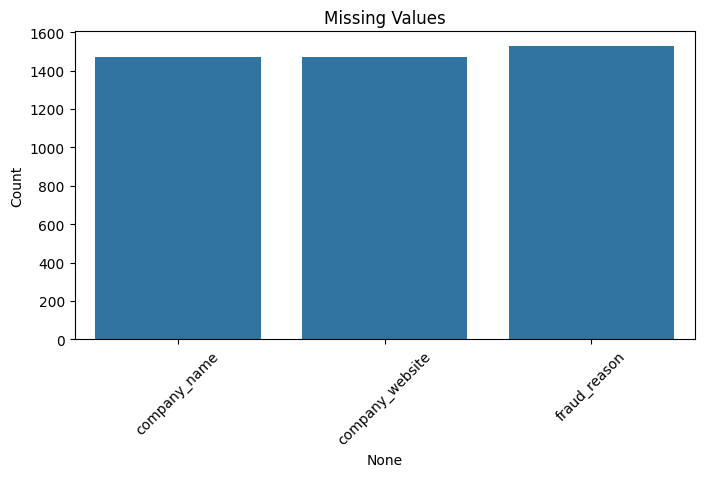

In [ ]:
plt.figure(figsize=(8,4))
sns.barplot(x=missing.index, y=missing.values)

plt.xticks(rotation=45)
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["is_fake"].value_counts()

,count
is_fake,
0,1528
1,1472


In [ ]:
df["is_fake"].value_counts(normalize=True) * 100

,proportion
is_fake,
0,50.933333
1,49.066667


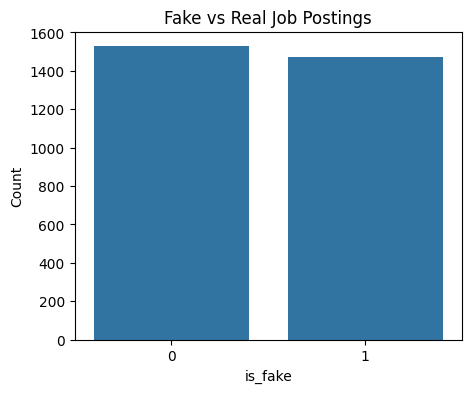

In [ ]:
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="is_fake")

plt.title("Fake vs Real Job Postings")
plt.xlabel("is_fake")
plt.ylabel("Count")

plt.show()

<Axes: >

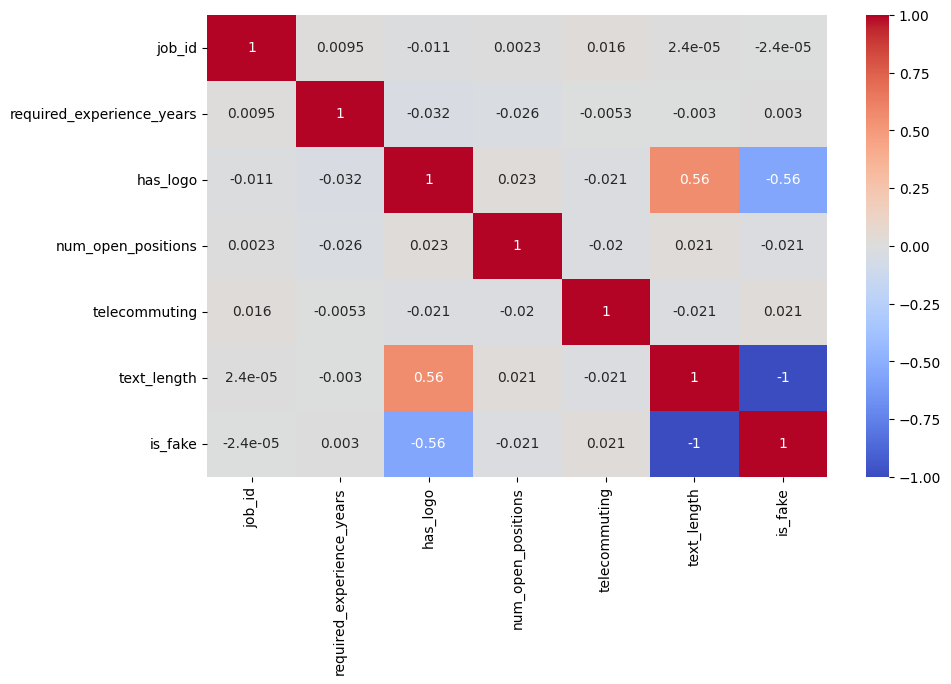

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [ ]:
df["company_name"] = df["company_name"].fillna("Unknown")

df["company_website"] = df["company_website"].fillna("Unknown")

df["fraud_reason"] = df["fraud_reason"].fillna("Not Applicable")

In [ ]:
df.isnull().sum()

,0
job_id,0
job_title,0
job_description,0
requirements,0
benefits,0
company_name,0
company_profile,0
industry,0
employment_type,0
location,0


In [ ]:
drop_cols = [
    "job_id",
    "posting_date",
    "application_deadline",
    "contact_email",
    "company_website",
    "salary_range",
    "fraud_reason",
    "text_length"
]

df.drop(columns=drop_cols, inplace=True)

In [ ]:
df["text"] = (
    df["job_title"].astype(str) + " " +
    df["job_description"].astype(str) + " " +
    df["requirements"].astype(str) + " " +
    df["benefits"].astype(str) + " " +
    df["company_profile"].astype(str)
)

In [ ]:
df[["text"]].head()

,text
0,Software Engineer We are looking for responsib...
1,Content Writer We are looking for required sup...
2,Customer Support Specialist We are looking for...
3,Data Analyst We are looking for collaboration ...
4,Graphic Designer We are looking for team growt...


In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = df["text"].apply(clean_text)

In [ ]:
print(df["text"].iloc[0])

software engineer we are looking for responsibilities fastpaced fastpaced growth development team innovation skills experience team dynamic fastpaced experience dynamic innovation fastpaced strategy responsibilities experience opportunity innovation required responsibilities growth dynamic required development team collaboration development preferred preferred responsibilities skills strategy development collaboration team knowledge preferred candidates should have dynamic team skills fastpaced knowledge team fastpaced development collaboration responsibilities strategy preferred opportunity preferred preferred dynamic responsibilities team opportunity fastpaced opportunity strategy collaboration responsibilities fastpaced we offer required skills fastpaced skills required collaboration responsibilities team dynamic required dynamic support collaboration strategy growth our company growth fastpaced responsibilities innovation collaboration preferred fastpaced growth support team skills

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

In [ ]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X = tfidf.fit_transform(df["text"])

y = df["is_fake"]

In [ ]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (3000, 39)
Target Shape: (3000,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



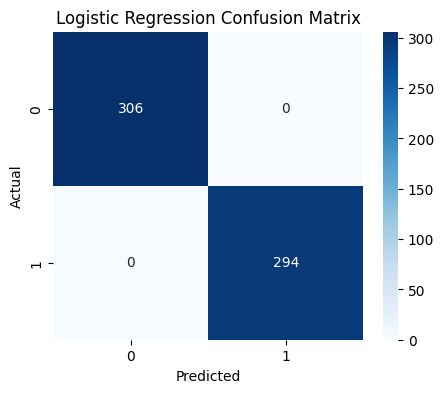

In [ ]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
nb = MultinomialNB()

nb.fit(X_train, y_train)

MultinomialNB()

In [ ]:
y_pred_nb = nb.predict(X_test)

In [ ]:
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [ ]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_nb),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_nb),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_nb),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Naive Bayes,1.0,1.0,1.0,1.0
2,Decision Tree,1.0,1.0,1.0,1.0
3,Random Forest,1.0,1.0,1.0,1.0


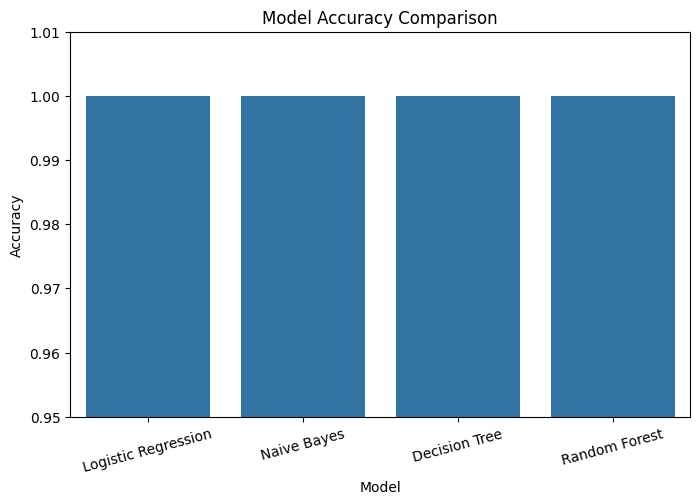

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(data=results, x="Model", y="Accuracy")

plt.xticks(rotation=15)
plt.ylim(0.95, 1.01)
plt.title("Model Accuracy Comparison")

plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["liblinear", "lbfgs"]
}

In [ ]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [ ]:
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Accuracy:", grid.best_score_)

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Best Cross Validation Accuracy: 1.0


In [ ]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test)

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       306
           1       1.00      1.00      1.00       294

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [ ]:
import joblib

In [ ]:
joblib.dump(best_lr, "job_fraud_model.pkl")

['job_fraud_model.pkl']

In [ ]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [ ]:
import os

print(os.listdir())

['.config', 'job_fraud_model.pkl', 'fake_real_job_postings_3000x25.csv', 'tfidf_vectorizer.pkl', 'sample_data']


In [ ]:
model = joblib.load("job_fraud_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def predict_job(text):
    text = clean_text(text)
    vector = vectorizer.transform([text])
    prediction = model.predict(vector)[0]

    if prediction == 0:
        return "✅ Legitimate Job Posting"
    else:
        return "❌ Fake Job Posting"

In [ ]:
real_job = """
Software Engineer

We are looking for a Python developer with experience in Django,
SQL, Git, REST APIs, and cloud platforms.
Health insurance, paid leave, and career growth provided.
"""

print(predict_job(real_job))

❌ Fake Job Posting


In [ ]:
#example 2
fake_job = """
Earn $8000 per week from home.

No experience required.

Send your bank details immediately.

Limited seats available.

Apply now.
"""

print(predict_job(fake_job))

❌ Fake Job Posting
